# Facial Emotion Recognition (FER) - Training Notebook

This notebook trains a deep CNN on the **FER2013** dataset for 7-class emotion recognition.

**Architecture highlights:**
- Inception-style multi-scale feature extraction (Mollahosseini et al.)
- Residual connections (Deepak et al.)
- Mixed precision training for T4 GPU speedup

**Reference:** Mellouk & Handouzi (2020). *Facial emotion recognition using deep learning: review and insights.*

## 1. Setup & GPU Check

In [7]:
# Install dependencies
!pip install -q kagglehub

import tensorflow as tf
import numpy as np
import os

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

# Enable mixed precision for T4 speedup
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print(f"Compute dtype: {mixed_precision.global_policy().compute_dtype}")
print(f"Variable dtype: {mixed_precision.global_policy().variable_dtype}")

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Compute dtype: float16
Variable dtype: float32


## 2. Dataset Loading

In [8]:
import kagglehub

# Download FER2013 dataset (msambare version with pre-organized folders)
path = kagglehub.dataset_download("msambare/fer2013")
print(f"Dataset downloaded to: {path}")

# Set directory paths
train_dir = os.path.join(path, 'train')
test_dir = os.path.join(path, 'test')

# Verify directory structure
print(f"\nTraining classes: {sorted(os.listdir(train_dir))}")
print(f"Test classes: {sorted(os.listdir(test_dir))}")

# Count images per class
print("\n--- Training set distribution ---")
total_train = 0
for cls in sorted(os.listdir(train_dir)):
    count = len(os.listdir(os.path.join(train_dir, cls)))
    total_train += count
    print(f"  {cls}: {count}")
print(f"  Total: {total_train}")

print("\n--- Test set distribution ---")
total_test = 0
for cls in sorted(os.listdir(test_dir)):
    count = len(os.listdir(os.path.join(test_dir, cls)))
    total_test += count
    print(f"  {cls}: {count}")
print(f"  Total: {total_test}")

Using Colab cache for faster access to the 'fer2013' dataset.
Dataset downloaded to: /kaggle/input/fer2013

Training classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Test classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

--- Training set distribution ---
  angry: 3995
  disgust: 436
  fear: 4097
  happy: 7215
  neutral: 4965
  sad: 4830
  surprise: 3171
  Total: 28709

--- Test set distribution ---
  angry: 958
  disgust: 111
  fear: 1024
  happy: 1774
  neutral: 1233
  sad: 1247
  surprise: 831
  Total: 7178


## 3. Data Preprocessing & Augmentation

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 48
BATCH_SIZE = 64
NUM_CLASSES = 7
EMOTIONS = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Training augmentation (critical for FER performance)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.15  # Use 15% of training data for validation
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nTraining samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Test samples: {test_generator.samples}")
print(f"Class indices: {train_generator.class_indices}")

Found 24406 images belonging to 7 classes.
Found 4303 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.

Training samples: 24406
Validation samples: 4303
Test samples: 7178
Class indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


## 4. Compute Class Weights

FER2013 has severe class imbalance (Disgust ~547 vs Happy ~8989). We compute inverse-frequency class weights to address this.

In [10]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights from training generator
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))

print("Class weights:")
for idx, emotion in enumerate(EMOTIONS):
    # Map using train_generator.class_indices
    gen_idx = train_generator.class_indices.get(emotion.lower(), idx)
    print(f"  {emotion} (idx {gen_idx}): {class_weight_dict.get(gen_idx, 1.0):.4f}")

Class weights:
  Angry (idx 0): 1.0267
  Disgust (idx 1): 9.3978
  Fear (idx 2): 1.0010
  Happy (idx 3): 0.5685
  Sad (idx 5): 0.8491
  Surprise (idx 6): 1.2932
  Neutral (idx 4): 0.8260


## 5. Model Architecture

Custom CNN inspired by:
- **Mollahosseini et al.** — Inception-style multi-scale convolutions
- **Deepak et al.** — Residual connections
- **Global Average Pooling** to reduce overfitting

In [11]:
from tensorflow.keras import layers, models, regularizers


def build_fer_model(input_shape=(48, 48, 1), num_classes=7):
    inputs = layers.Input(shape=input_shape)

    # Block 1: Initial feature extraction
    x = layers.Conv2D(64, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Block 2: Deeper features
    x = layers.Conv2D(128, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Block 3: Inception-inspired module (Mollahosseini et al.)
    # Branch 1: 1x1 conv
    branch1 = layers.Conv2D(64, (1, 1), padding='same', activation='relu')(x)
    # Branch 2: 3x3 conv
    branch2 = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    # Branch 3: 5x5 conv
    branch3 = layers.Conv2D(64, (5, 5), padding='same', activation='relu')(x)

    x = layers.Concatenate()([branch1, branch2, branch3])
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Block 4: Residual block (Deepak et al.)
    shortcut = layers.Conv2D(256, (1, 1), padding='same')(x)
    shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Conv2D(256, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(256, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)

    x = layers.Add()([x, shortcut])  # Residual connection
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)

    # Output — keep float32 for mixed precision stability
    outputs = layers.Dense(num_classes, dtype='float32')(x)
    outputs = layers.Activation('softmax')(outputs)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model


model = build_fer_model()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 48, 48,    │        640 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 48, 48,    │     36,928 │ activation_9[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 24, 24,    │          0 │ activation_10[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 24, 24,    │          0 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 24, 24,    │     73,856 │ dropout_6[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        512 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 24, 24,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 24, 24,    │    147,584 │ activation_11[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        512 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 24, 24,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 12, 12,    │          0 │ activation_12[0]… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 12, 12,    │          0 │ max_pooling2d_5[

 Total params: 1,901,191 (7.25 MB)

 Trainable params: 1,896,967 (7.24 MB)

 Non-trainable params: 4,224 (16.50 KB)

## 6. Compile & Train

In [12]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
)

# Compile
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    ModelCheckpoint(
        'best_fer_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    CSVLogger('training_log.csv')
]

EPOCHS = 100

# Train with class weights to handle imbalance
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

Epoch 1/100
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.1539 - loss: 2.4886
Epoch 1: val_accuracy improved from None to 0.25029, saving model to best_fer_model.keras

Epoch 1: finished saving model to best_fer_model.keras
382/382 ━━━━━━━━━━━━━━━━━━━━ 165s 352ms/step - accuracy: 0.1573 - loss: 2.3544 - val_accuracy: 0.2503 - val_loss: 2.0621 - learning_rate: 0.0010
Epoch 2/100
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.1637 - loss: 2.1841
Epoch 2: val_accuracy did not improve from 0.25029
382/382 ━━━━━━━━━━━━━━━━━━━━ 33s 86ms/step - accuracy: 0.1698 - loss: 2.1520 - val_accuracy: 0.1571 - val_loss: 2.0876 - learning_rate: 0.0010
Epoch 3/100
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.1811 - loss: 2.0517
Epoch 3: val_accuracy did not improve from 0.25029
382/382 ━━━━━━━━━━━━━━━━━━━━ 36s 95ms/step - accuracy: 0.1880 - loss: 2.0451 - val_accuracy: 0.1411 - val_loss: 2.0499 - learning_rate: 0.0010
Epoch 4/100
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - 

## 7. Evaluation & Metrics

113/113 ━━━━━━━━━━━━━━━━━━━━ 28s 232ms/step - accuracy: 0.6570 - loss: 1.0722

Test Loss: 1.0722
Test Accuracy: 0.6570
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step

Class ordering: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry       0.58      0.61      0.59       958
     disgust       0.58      0.67      0.62       111
        fear       0.55      0.32      0.40      1024
       happy       0.92      0.83      0.87      1774
     neutral       0.57      0.70      0.63      1233
         sad       0.52      0.57      0.54      1247
    surprise       0.72      0.82      0.76       831

    accuracy                           0.66      7178
   macro avg       0.63      0.65      0.63      7178
weighted avg       0.66      0.66      0.65      7178



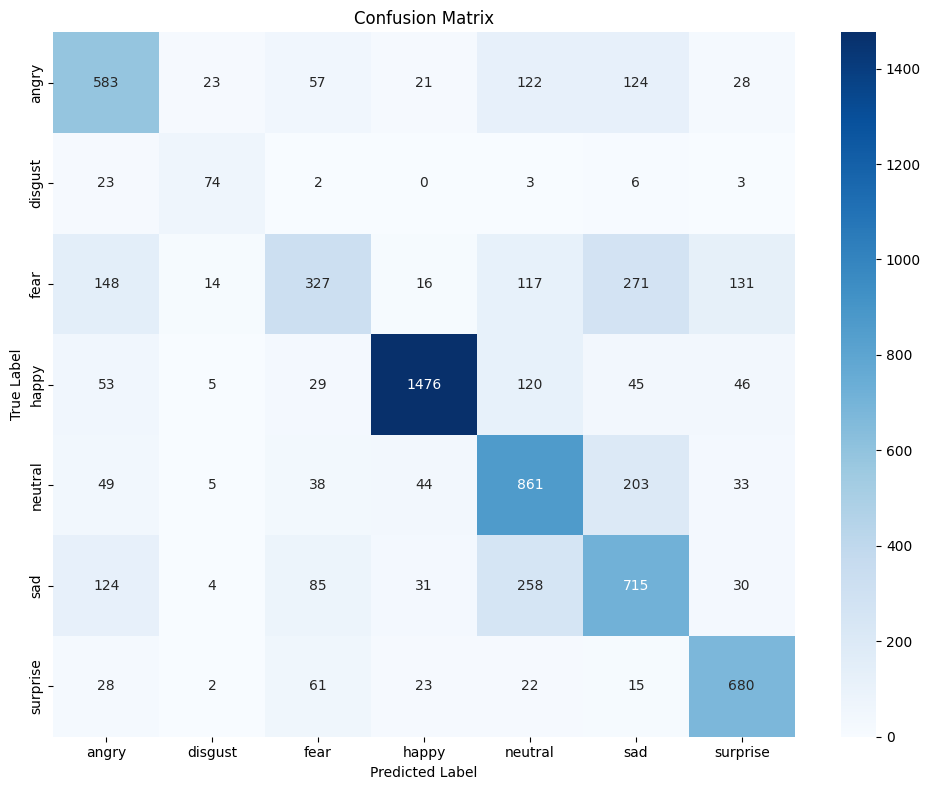

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load best model
model = tf.keras.models.load_model('best_fer_model.keras')

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Predictions
test_generator.reset()
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

# Map class indices to emotion names
# The generator uses alphabetical ordering of folder names
class_labels = list(test_generator.class_indices.keys())
print(f"\nClass ordering: {class_labels}")

# Classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## 8. Training History Plots

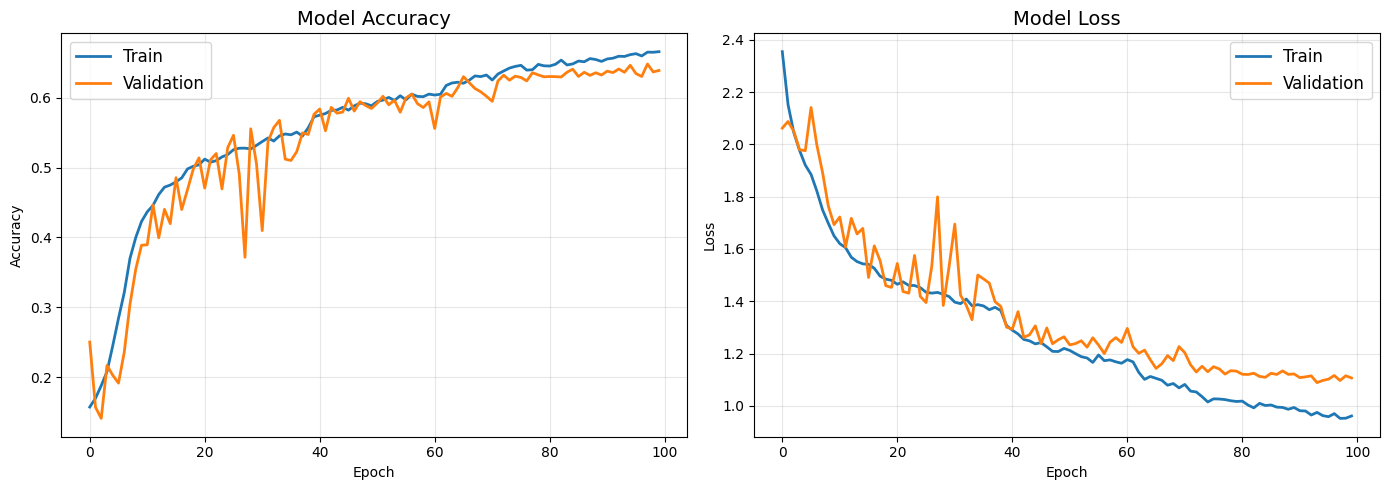


Best validation accuracy: 0.6482
Final training accuracy: 0.6658


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Train', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
ax1.set_title('Model Accuracy', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history.history['loss'], label='Train', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation', linewidth=2)
ax2.set_title('Model Loss', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

print(f"\nBest validation accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")

## 9. Export Model & Artifacts

Save all artifacts needed for the Streamlit app deployment.

In [15]:
import json

# Save model in multiple formats
model.save('fer_model.keras')  # Full Keras format
model.save('fer_model.h5')    # Legacy H5 format for broad compatibility
print("Models saved: fer_model.keras, fer_model.h5")

# Save training history as JSON
history_dict = {
    k: [float(v) for v in vals]
    for k, vals in history.history.items()
}
with open('training_history.json', 'w') as f:
    json.dump(history_dict, f, indent=2)
print("Saved: training_history.json")

# Save classification report as JSON
report = classification_report(
    y_true, y_pred_classes,
    target_names=class_labels,
    output_dict=True
)
with open('classification_report.json', 'w') as f:
    json.dump(report, f, indent=2)
print("Saved: classification_report.json")

# Save confusion matrix
np.save('confusion_matrix.npy', cm)
print("Saved: confusion_matrix.npy")

print("\n" + "="*60)
print("All artifacts saved successfully!")
print("="*60)

Models saved: fer_model.keras, fer_model.h5
Saved: training_history.json
Saved: classification_report.json
Saved: confusion_matrix.npy

All artifacts saved successfully!


## 10. Download Artifacts

Download the files needed for the Streamlit app. Place them in the `models/` directory.

In [16]:
from google.colab import files

print("Downloading model and artifacts...")
print("Place these files in the 'models/' directory of your Streamlit project.\n")

files.download('fer_model.h5')
files.download('training_history.json')
files.download('classification_report.json')
files.download('confusion_matrix.npy')
files.download('training_curves.png')
files.download('confusion_matrix.png')

print("\nAll files downloaded!")
print("\nRequired files for Streamlit app:")
print("  models/fer_model.h5")
print("  models/training_history.json")
print("  models/classification_report.json")
print("  models/confusion_matrix.npy")

Place these files in the 'models/' directory of your Streamlit project.



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All files downloaded!

Required files for Streamlit app:
  models/fer_model.h5
  models/training_history.json
  models/classification_report.json
  models/confusion_matrix.npy


In [19]:
# ==============================
# IMPORTS
# ==============================
from google.colab import drive
import shutil
import os

# ==============================
# MOUNT GOOGLE DRIVE
# ==============================
drive.mount('/content/drive')

# ==============================
# CREATE OUTPUT DIRECTORY
# ==============================
output_dir = '/content/drive/MyDrive/FER_Artifacts'
os.makedirs(output_dir, exist_ok=True)

# ==============================
# LIST OF FILES TO SAVE
# ==============================
artifacts = [
    'fer_model.h5',
    'training_history.json',
    'classification_report.json',
    'confusion_matrix.npy',
    'training_curves.png',
    'confusion_matrix.png',
]

# ==============================
# COPY FILES TO GOOGLE DRIVE
# ==============================
copied = 0
skipped = 0

for f in artifacts:
    if os.path.exists(f):
        destination = os.path.join(output_dir, os.path.basename(f))
        shutil.copy(f, destination)
        print(f"✅ Copied: {f}")
        copied += 1
    else:
        print(f"⚠️ Skipped (not found): {f}")
        skipped += 1

# ==============================
# FINAL SUMMARY
# ==============================
print("\n==============================")
print(f"✔️ Copied files: {copied}")
print(f"⚠️ Skipped files: {skipped}")
print(f"\n📁 Saved to: {output_dir}")

print("\n📦 Required files for Streamlit app:")
print("  models/fer_model.h5")
print("  models/training_history.json")
print("  models/classification_report.json")
print("  models/confusion_matrix.npy")
print("==============================")

Mounted at /content/drive
✅ Copied: fer_model.h5
✅ Copied: training_history.json
✅ Copied: classification_report.json
✅ Copied: confusion_matrix.npy
✅ Copied: training_curves.png
✅ Copied: confusion_matrix.png

✔️ Copied files: 6
⚠️ Skipped files: 0

📁 Saved to: /content/drive/MyDrive/FER_Artifacts

📦 Required files for Streamlit app:
  models/fer_model.h5
  models/training_history.json
  models/classification_report.json
  models/confusion_matrix.npy
